In [1]:
# import python libraries

import numpy as np
from scipy.optimize import brentq
import matplotlib.pyplot as plt
import matplotlib

In [2]:
# some values used for calculations

k = 8.61733e-5; # boltzmann constant in eV/K
TK = 1000+273; # equilibrium temp in K
TC = TK-273; # equilibrium temp in C
TQK = 900+273;# quenched temp in K
TQC = TQK-273; # quenched temp in C
a = np.logspace(-20,5,200); # oxygen partial pressure range
# print(
#     f'a[154] = {a[154]:.2} atm'
# ) # pO2~0.21 atm

In [11]:
# Equilibrium defect reaction constants

# KR = 1.27E51
KR = 1.06E71*np.exp(-5.69/(k*TK))
Ki = 4.67E33

# Hagemann, H‐J., and D. Hennings. "Reversible weight change of acceptor‐doped BaTiO3." Journal of the American Ceramic Society 64, no. 10 (1981): 590-594.
KMn43 = 2.9E18
KMn32 = 4.9e16

print(
    f'at T = {TC} \u00B0C\n'
    f'Ki = {Ki:.2e}\n'
    f'KR = {KR:.2e}\n'
    f'KMn43 = {KMn43:.2e}\n'
    f'KMn32 = {KMn32:.2e}\n'
)


at T = 1000 °C
Ki = 4.67e+33
KR = 3.15e+48
KMn43 = 2.90e+18
KMn32 = 4.90e+16



In [8]:
# empty lists for each defect concentration; will be filled later
# Mn+Y co-doped & A/B = 1.000 / 0.999 / 0.994 & high T eq / low T quenched

CVO2_MnY_1000e = np.zeros(len(a))
CVO2_MnY_1000q = np.zeros(len(a))
CVO2_MnY_999e = np.zeros(len(a))
CVO2_MnY_999q = np.zeros(len(a))
CVO2_MnY_994e = np.zeros(len(a))
CVO2_MnY_994q = np.zeros(len(a))

CVTi4_MnY_1000e = np.zeros(len(a))
CVTi4_MnY_1000q = np.zeros(len(a))
CVTi4_MnY_999e = np.zeros(len(a))
CVTi4_MnY_999q = np.zeros(len(a))
CVTi4_MnY_994e = np.zeros(len(a))
CVTi4_MnY_994q = np.zeros(len(a))

CVBa2_MnY_1000e = np.zeros(len(a))
CVBa2_MnY_1000q = np.zeros(len(a))
CVBa2_MnY_999e = np.zeros(len(a))
CVBa2_MnY_999q = np.zeros(len(a))
CVBa2_MnY_994e = np.zeros(len(a))
CVBa2_MnY_994q = np.zeros(len(a))

n_MnY_1000e = np.zeros(len(a))
n_MnY_1000q = np.zeros(len(a))
n_MnY_999e = np.zeros(len(a))
n_MnY_999q = np.zeros(len(a))
n_MnY_994e = np.zeros(len(a))
n_MnY_994q = np.zeros(len(a))

p_MnY_1000e = np.zeros(len(a))
p_MnY_1000q = np.zeros(len(a))
p_MnY_999e = np.zeros(len(a))
p_MnY_999q = np.zeros(len(a))
p_MnY_994e = np.zeros(len(a))
p_MnY_994q = np.zeros(len(a))

CMn0_MnY_1000e = np.zeros(len(a))
CMn1_MnY_1000e = np.zeros(len(a))
CMn2_MnY_1000e = np.zeros(len(a))

CMn0_MnY_1000q = np.zeros(len(a))
CMn1_MnY_1000q = np.zeros(len(a))
CMn2_MnY_1000q = np.zeros(len(a))

CMn0_MnY_999e = np.zeros(len(a))
CMn1_MnY_999e = np.zeros(len(a))
CMn2_MnY_999e = np.zeros(len(a))

CMn0_MnY_999q = np.zeros(len(a))
CMn1_MnY_999q = np.zeros(len(a))
CMn2_MnY_999q = np.zeros(len(a))

CMn0_MnY_994e = np.zeros(len(a))
CMn1_MnY_994e = np.zeros(len(a))
CMn2_MnY_994e = np.zeros(len(a))

CMn0_MnY_994q = np.zeros(len(a))
CMn1_MnY_994q = np.zeros(len(a))
CMn2_MnY_994q = np.zeros(len(a))

Mn+Y co-doped & A/B = 1.0 & T = 1000 °C
at pO2 ~ 0.21 atm
n = 3.75e+17
p = 1.24e+16
[VO2+] = 1.91e+16
[Mnt] = 7.70e+19
[Mn0] = 3.63e+19
[Mn1-] = 4.70e+18
[Mn2-] = 3.60e+19
[YBa1+] = 7.70e+19


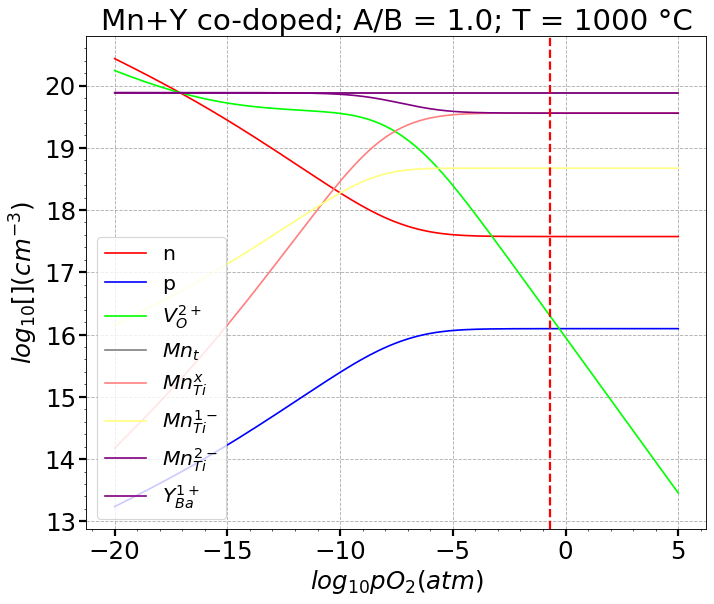

In [9]:
"""
[19] Mn+Y co-doped & A/B = 1.000 & high T eq

Charge neutrality condition: p + 2[VO2+] + [YBa1+] = n + 2[VBa2-] + 4[VTi4-] + [MnTi1-] + 2[MnTi2-]
    where [VBa2-] = [VTi4-] with full Schottky reaction
"""
ratio = 1.000
CMnt = 7.7E19 # total Mn concentration in cm-3; 7.7E19 cm-3 = 0.5 mol% in BTO
CYt = 7.7E19 # total Y concentration in cm-3; 7.7E19 cm-3 = 0.5 mol% in BTO
CY = np.zeros(len(a))

# Calculate each defect concentration as a function of oxygen partial pressure
for i in range(len(a)): 
    y = a[i] # y: oxygen partial pressure in atm
    
    def f(x): # x: electron concentration in cm-3
        return (x + CMnt + CMnt*(Ki/KMn43)*((Ki/KMn32)*x/Ki - Ki/((Ki/KMn43)*x))/(Ki/x + Ki/KMn43 + (Ki/KMn43)*(Ki/KMn32)*x/Ki) - (Ki/x) - 2*(KR/((x**2)*(y**(1/2)))) - CYt)
    sol1 = brentq(f,1E10,1E30,maxiter=200)
    
    n_MnY_1000e[i] = np.array(sol1).astype(np.float64)
    p_MnY_1000e[i] = Ki/n_MnY_1000e[i]
    CVO2_MnY_1000e[i] = KR/((n_MnY_1000e[i]**2)*(y**(1/2)))
    CMn1_MnY_1000e[i] = CMnt*(Ki/KMn43)/(p_MnY_1000e[i] + Ki/KMn43 + (Ki/KMn43)*(Ki/KMn32)/p_MnY_1000e[i])
    CMn2_MnY_1000e[i] = (Ki/KMn32)*CMn1_MnY_1000e[i]/p_MnY_1000e[i]
    CMn0_MnY_1000e[i] = CMnt - CMn1_MnY_1000e[i] - CMn2_MnY_1000e[i]
    CY[i] = CYt

fig = plt.figure(figsize=(10, 8), dpi=80)
ax1= plt.subplot(111)
ax1.set_title(f'Mn+Y co-doped; A/B = {ratio}; T = {TC} \u00B0C')
# ax1.set_ylim(ymin=13, ymax=21)
matplotlib.rcParams.update({'font.size': 22})
ax1.tick_params(length=6, width=2)
ax1.minorticks_on()
ax1.plot(np.log10(a),np.log10(n_MnY_1000e),c =[255/255, 0/255, 0/255], label=r'n')
ax1.plot(np.log10(a),np.log10(p_MnY_1000e), c =[0/255, 0/255, 255/255], label = r'p')
ax1.plot(np.log10(a),np.log10(CVO2_MnY_1000e),c =[0/255, 255/255, 0/255], label = r'$V_O^{2+}$')
ax1.plot(np.log10(a),np.log10(CMn1_MnY_1000e+CMn2_MnY_1000e+CMn0_MnY_1000e), c =[128/255, 128/255, 128/255], label = r'$Mn_{t}$')
ax1.plot(np.log10(a),np.log10(CMn0_MnY_1000e), c =[255/255, 128/255, 128/255], label = r'$Mn_{Ti}^{x}$')
ax1.plot(np.log10(a),np.log10(CMn1_MnY_1000e), c =[255/255, 255/255, 128/255], label = r'$Mn_{Ti}^{1-}$')
ax1.plot(np.log10(a),np.log10(CMn2_MnY_1000e), c =[128/255, 0/255, 128/255], label = r'$Mn_{Ti}^{2-}$')
ax1.plot(np.log10(a),np.log10(CY), c =[128/255, 0/255, 128/255], label = r'$Y_{Ba}^{1+}$')
ax1.set_xlabel(r'$log_{10} \mathit{p}O_2 (atm)$')
ax1.set_ylabel(r'$log_{10} [ ] (cm^{-3})$')
ax1.legend(loc=3,fontsize='small')
ax1.axvline(x=-0.67, color='r', linestyle='--', linewidth=2)
ax1.grid(True, which='major', linestyle='--')

print(
    f'Mn+Y co-doped & A/B = {ratio} & T = {TC} \u00B0C\n'
    f'at pO2 ~ 0.21 atm\n'
    f'n = {n_MnY_1000e[154]:.2e}\n'
    f'p = {p_MnY_1000e[154]:.2e}\n'
    f'[VO2+] = {CVO2_MnY_1000e[154]:.2e}\n'
    f'[Mnt] = {CMn1_MnY_1000e[154]+CMn2_MnY_1000e[154]+CMn0_MnY_1000e[154]:.2e}\n'
    f'[Mn0] = {CMn0_MnY_1000e[154]:.2e}\n'
    f'[Mn1-] = {CMn1_MnY_1000e[154]:.2e}\n'
    f'[Mn2-] = {CMn2_MnY_1000e[154]:.2e}\n'
    f'[YBa1+] = {CY[154]:.2e}'
)

Mn+Y co-doped & A/B = 1.0 & T = 1000 °C
at pO2 ~ 0.21 atm
n = 1.27e+16
p = 3.67e+17
[VO2+] = 4.13e+16
[Mnt] = 7.70e+19
[Mn0] = 7.73e+18
[Mn1-] = 6.11e+19
[Mn2-] = 8.16e+18
[YBa1+] = 7.70e+19


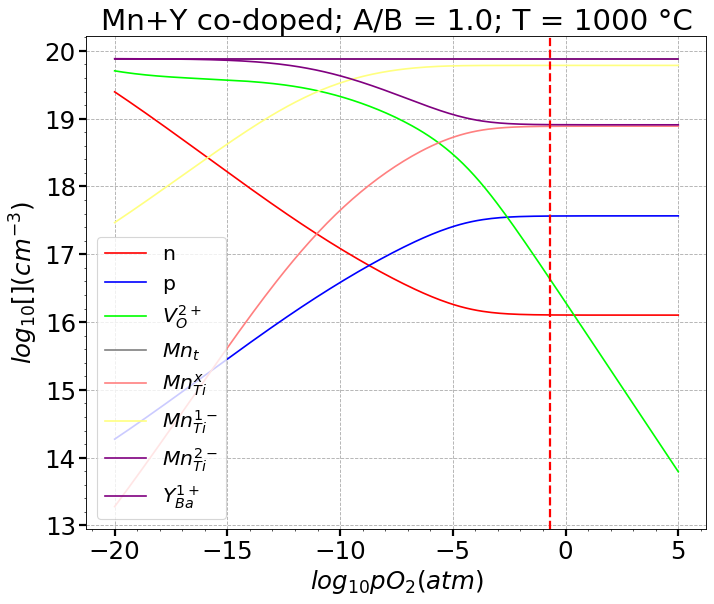

In [12]:
"""
[19] Mn+Y co-doped & A/B = 1.000 & high T eq

Charge neutrality condition: p + 2[VO2+] + [YBa1+] = n + 2[VBa2-] + 4[VTi4-] + [MnTi1-] + 2[MnTi2-]
    where [VBa2-] = [VTi4-] with full Schottky reaction
"""
ratio = 1.000
CMnt = 7.7E19 # total Mn concentration in cm-3; 7.7E19 cm-3 = 0.5 mol% in BTO
CYt = 7.7E19 # total Y concentration in cm-3; 7.7E19 cm-3 = 0.5 mol% in BTO
CY = np.zeros(len(a))

# Calculate each defect concentration as a function of oxygen partial pressure
for i in range(len(a)): 
    y = a[i] # y: oxygen partial pressure in atm
    
    def f(x): # x: electron concentration in cm-3
        return (x + CMnt + CMnt*KMn43*(KMn32*x/Ki - Ki/(KMn43*x))/(Ki/x + KMn43 + KMn43*KMn32*x/Ki) - (Ki/x) - 2*(KR/((x**2)*(y**(1/2)))) - CYt)
    sol1 = brentq(f,1E10,1E30,maxiter=200)
    
    n_MnY_1000e[i] = np.array(sol1).astype(np.float64)
    p_MnY_1000e[i] = Ki/n_MnY_1000e[i]
    CVO2_MnY_1000e[i] = KR/((n_MnY_1000e[i]**2)*(y**(1/2)))
    CMn1_MnY_1000e[i] = CMnt*KMn43/(p_MnY_1000e[i] + KMn43 + KMn43*KMn32/p_MnY_1000e[i])
    CMn2_MnY_1000e[i] = KMn32*CMn1_MnY_1000e[i]/p_MnY_1000e[i]
    CMn0_MnY_1000e[i] = CMnt - CMn1_MnY_1000e[i] - CMn2_MnY_1000e[i]
    CY[i] = CYt

fig = plt.figure(figsize=(10, 8), dpi=80)
ax1= plt.subplot(111)
ax1.set_title(f'Mn+Y co-doped; A/B = {ratio}; T = {TC} \u00B0C')
# ax1.set_ylim(ymin=13, ymax=21)
matplotlib.rcParams.update({'font.size': 22})
ax1.tick_params(length=6, width=2)
ax1.minorticks_on()
ax1.plot(np.log10(a),np.log10(n_MnY_1000e),c =[255/255, 0/255, 0/255], label=r'n')
ax1.plot(np.log10(a),np.log10(p_MnY_1000e), c =[0/255, 0/255, 255/255], label = r'p')
ax1.plot(np.log10(a),np.log10(CVO2_MnY_1000e),c =[0/255, 255/255, 0/255], label = r'$V_O^{2+}$')
ax1.plot(np.log10(a),np.log10(CMn1_MnY_1000e+CMn2_MnY_1000e+CMn0_MnY_1000e), c =[128/255, 128/255, 128/255], label = r'$Mn_{t}$')
ax1.plot(np.log10(a),np.log10(CMn0_MnY_1000e), c =[255/255, 128/255, 128/255], label = r'$Mn_{Ti}^{x}$')
ax1.plot(np.log10(a),np.log10(CMn1_MnY_1000e), c =[255/255, 255/255, 128/255], label = r'$Mn_{Ti}^{1-}$')
ax1.plot(np.log10(a),np.log10(CMn2_MnY_1000e), c =[128/255, 0/255, 128/255], label = r'$Mn_{Ti}^{2-}$')
ax1.plot(np.log10(a),np.log10(CY), c =[128/255, 0/255, 128/255], label = r'$Y_{Ba}^{1+}$')
ax1.set_xlabel(r'$log_{10} \mathit{p}O_2 (atm)$')
ax1.set_ylabel(r'$log_{10} [ ] (cm^{-3})$')
ax1.legend(loc=3,fontsize='small')
ax1.axvline(x=-0.67, color='r', linestyle='--', linewidth=2)
ax1.grid(True, which='major', linestyle='--')

print(
    f'Mn+Y co-doped & A/B = {ratio} & T = {TC} \u00B0C\n'
    f'at pO2 ~ 0.21 atm\n'
    f'n = {n_MnY_1000e[154]:.2e}\n'
    f'p = {p_MnY_1000e[154]:.2e}\n'
    f'[VO2+] = {CVO2_MnY_1000e[154]:.2e}\n'
    f'[Mnt] = {CMn1_MnY_1000e[154]+CMn2_MnY_1000e[154]+CMn0_MnY_1000e[154]:.2e}\n'
    f'[Mn0] = {CMn0_MnY_1000e[154]:.2e}\n'
    f'[Mn1-] = {CMn1_MnY_1000e[154]:.2e}\n'
    f'[Mn2-] = {CMn2_MnY_1000e[154]:.2e}\n'
    f'[YBa1+] = {CY[154]:.2e}'
)

/tmp/ipykernel_9349/1276757136.py:38: RuntimeWarning: divide by zero encountered in log10
  ax1.plot(np.log10(a),np.log10(CVBa2_MnY_1000q), c =[255/255, 0/255, 128/255], label = r'$V_{Ba}^{2-}, V_{Ti}^{4-}$')
/tmp/ipykernel_9349/1276757136.py:40: RuntimeWarning: invalid value encountered in log10
  ax1.plot(np.log10(a),np.log10(CMn0_MnY_1000q), c =[255/255, 128/255, 128/255], label = r'$Mn_{Ti}^{x}$')


Mn+Y co-doped & A/B = 1.0 & T = 900 °C
at pO2 ~ 0.21 atm
n = 1.94e+16
p = 2.40e+17
[VO2+] = 7.13e+18
[VBa2-] = 0.00e+00
[VTi4-] = 0.00e+00
[Mnt] = 1.54e+20
[Mn0] = -1.31e+19
[Mn1-] = 1.20e+20
[Mn2-] = 4.75e+19
[YBa1+] = 1.54e+20


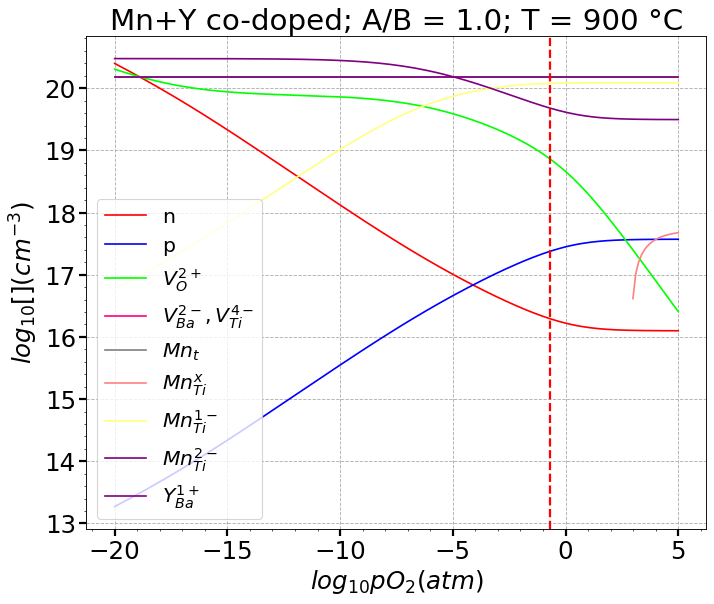

In [12]:
"""
[22] Mn+Y co-doped & A/B = 1.000 & low T quenched

Charge neutrality condition: p + 2[VO2+] + [YBa1+] = n + 2[VBa2-] + 4[VTi4-] + [MnTi1-] + 2[MnTi2-]
    where [VBa2-] = [VTi4-] with full Schottky reaction & ionic defects (VO2 & VBa2 & VTi4) frozen-in from high T eq to low T quenched state
"""
ratio = 1.000
CMnt = 2*7.7E19 # total Mn concentration in cm-3; 7.7E19 cm-3 = 0.5 mol% in BTO
CYt = 2*7.7E19 # total Y concentration in cm-3; 7.7E19 cm-3 = 0.5 mol% in BTO
CY = np.zeros(len(a))

# Calculate each defect concentration as a function of oxygen partial pressure
for i in range(len(a)): 
    y = a[i] # y: oxygen partial pressure in atm
    
    def f(x): # x: electron concentration in cm-3
        return (x + CMnt + CMnt*KMn43*(KMn32*x/Ki - Ki/(KMn43*x))/(Ki/x + KMn43 + KMn43*KMn32*x/Ki) - (Ki/x) - 2*CVO2_MnY_1000e[i] - CYt)
    sol1 = brentq(f,1,1E30)
    
    n_MnY_1000q[i] = np.array(sol1).astype(np.float64)
    p_MnY_1000q[i] = Ki/n_MnY_1000q[i]
    CVO2_MnY_1000q[i] = CVO2_MnY_1000e[i]
    CMn1_MnY_1000q[i] = CMnt*KMn43/(p_MnY_1000q[i] + KMn43 + KMn43*KMn32/p_MnY_1000q[i])
    CMn2_MnY_1000q[i] = CMn1_MnY_1000q[i]*n_MnY_1000q[i]/KMn32
    CMn0_MnY_1000q[i] = CMnt - CMn1_MnY_1000q[i] - CMn2_MnY_1000q[i]
    CY[i] = CYt

fig = plt.figure(figsize=(10, 8), dpi=80)
ax1= plt.subplot(111)
ax1.set_title(f'Mn+Y co-doped; A/B = {ratio}; T = {TQC} \u00B0C')
# ax1.set_ylim(ymin=13, ymax=21)
matplotlib.rcParams.update({'font.size': 22})
ax1.tick_params(length=6, width=2)
ax1.minorticks_on()
ax1.plot(np.log10(a),np.log10(n_MnY_1000q),c =[255/255, 0/255, 0/255], label=r'n')
ax1.plot(np.log10(a),np.log10(p_MnY_1000q), c =[0/255, 0/255, 255/255], label = r'p')
ax1.plot(np.log10(a),np.log10(CVO2_MnY_1000q),c =[0/255, 255/255, 0/255], label = r'$V_O^{2+}$')
ax1.plot(np.log10(a),np.log10(CVBa2_MnY_1000q), c =[255/255, 0/255, 128/255], label = r'$V_{Ba}^{2-}, V_{Ti}^{4-}$')
ax1.plot(np.log10(a),np.log10(CMn1_MnY_1000q+CMn2_MnY_1000q+CMn0_MnY_1000q), c =[128/255, 128/255, 128/255], label = r'$Mn_{t}$')
ax1.plot(np.log10(a),np.log10(CMn0_MnY_1000q), c =[255/255, 128/255, 128/255], label = r'$Mn_{Ti}^{x}$')
ax1.plot(np.log10(a),np.log10(CMn1_MnY_1000q), c =[255/255, 255/255, 128/255], label = r'$Mn_{Ti}^{1-}$')
ax1.plot(np.log10(a),np.log10(CMn2_MnY_1000q), c =[128/255, 0/255, 128/255], label = r'$Mn_{Ti}^{2-}$')
ax1.plot(np.log10(a),np.log10(CY), c =[128/255, 0/255, 128/255], label = r'$Y_{Ba}^{1+}$')
ax1.set_xlabel(r'$log_{10} \mathit{p}O_2 (atm)$')
ax1.set_ylabel(r'$log_{10} [ ] (cm^{-3})$')
ax1.legend(loc=3,fontsize='small')
ax1.axvline(x=-0.67, color='r', linestyle='--', linewidth=2)
ax1.grid(True, which='major', linestyle='--')

print(
    f'Mn+Y co-doped & A/B = {ratio} & T = {TQC} \u00B0C\n'
    f'at pO2 ~ 0.21 atm\n'
    f'n = {n_MnY_1000q[154]:.2e}\n'
    f'p = {p_MnY_1000q[154]:.2e}\n'
    f'[VO2+] = {CVO2_MnY_1000q[154]:.2e}\n'
    f'[VBa2-] = {CVBa2_MnY_1000q[154]:.2e}\n'
    f'[VTi4-] = {CVTi4_MnY_1000q[154]:.2e}\n'
    f'[Mnt] = {CMn1_MnY_1000q[154]+CMn2_MnY_1000q[154]+CMn0_MnY_1000q[154]:.2e}\n'
    f'[Mn0] = {CMn0_MnY_1000q[154]:.2e}\n'
    f'[Mn1-] = {CMn1_MnY_1000q[154]:.2e}\n'
    f'[Mn2-] = {CMn2_MnY_1000q[154]:.2e}\n'
    f'[YBa1+] = {CY[154]:.2e}'
)